In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Period & Domain

In [2]:
iyear=1960
fyear=2024
nx=10;ny=10
dom='GRq'
dom_NST = 'GRc'
year_NST = '2000'

# SMB Data

In [3]:
SMB = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SMB_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SMB']

#Domain & period def
SMB = SMB.rename({'TIME': 'time'})
SMB = SMB[:,:,ny:-ny,nx:-nx].sel(time=slice(str(iyear),str(fyear)))

# .isel(SECTOR=0) = ICE domain / .isel(SECTOR=1) = partout ou presque je sais plus
SMB = SMB.isel(SECTOR=0)

# ICE mask

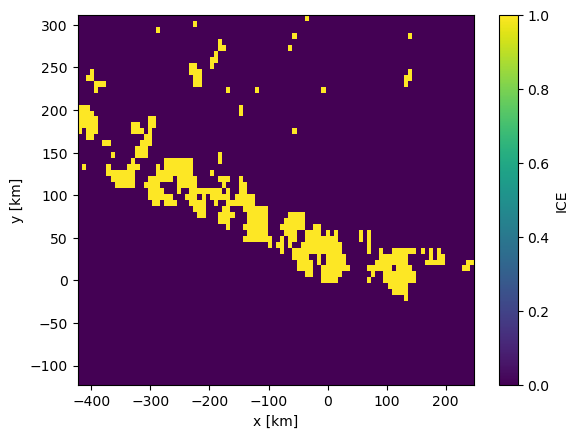

In [4]:
# ICE data
ds_grM= xr.open_dataset(f'/home/santolam/NST.{year_NST}.01.01.00.{dom_NST}.nc')
dsICE = ds_grM.ICE[ny:-ny,nx:-nx]

#ICE mask
ICE_mask = dsICE > 0
ICE_mask = ICE_mask.rename({'x': 'X', 'y': 'Y'})
ICE_mask.plot()

In [5]:
ICE_mask = ICE_mask.assign_coords({
    "X": SMB.X,
    "Y": SMB.Y
})
SMB = SMB.where(ICE_mask)

# Annual Mean

In [6]:
SMB_mean = SMB.groupby('time.year').mean('time', skipna=True)
SMB_mean = SMB_mean.mean(dim=['Y','X'], skipna=True)

# Trends

In [7]:
mask = ~np.isnan(SMB_mean.values)
slope_SMB, intercept_SMB, r_value_SMB, p_value_SMB, std_err_SMB = stats.linregress(SMB_mean['year'].values[mask], SMB_mean.values[mask])
trend_SMB = intercept_SMB + slope_SMB * SMB_mean['year'].values

# Statistics

In [8]:
mean_SMB = np.nanmean(SMB_mean.values)
std_SMB = np.nanstd(SMB_mean.values)
min_SMB = np.nanmin(SMB_mean.values)
max_SMB = np.nanmax(SMB_mean.values)

SMB : -5.93 mm w.e. / month / decade (p=0.001) (-10.1 %/decade) (std=45.8 %)



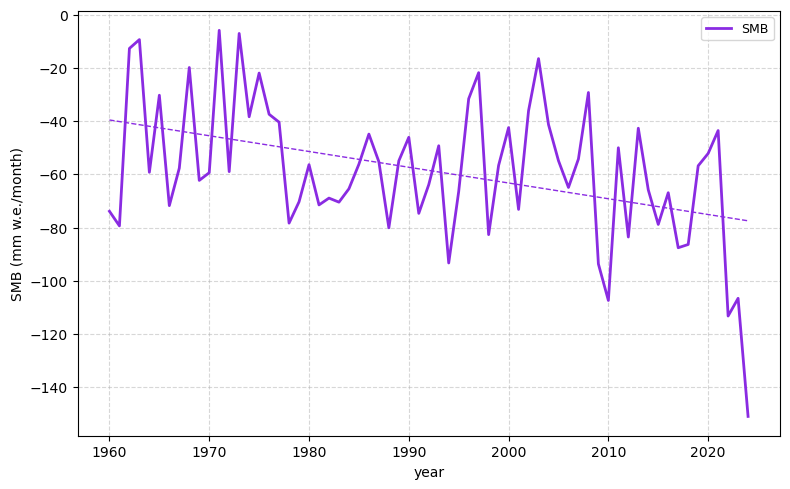

In [9]:
print(f'SMB : {slope_SMB * 10:.2f} mm w.e. / month / decade (p={p_value_SMB:.3f}) ({(slope_SMB*10)/np.abs(mean_SMB)*100:.1f} %/decade) (std={np.abs(std_SMB/mean_SMB*100):.1f} %)\n')

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(SMB_mean['year'].values, SMB_mean.values, color='blueviolet', label='SMB', linewidth=2)
ax.plot(SMB_mean['year'].values, trend_SMB, color='blueviolet', linewidth=1, linestyle='--')

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel('year')
ax.set_ylabel('SMB (mm w.e./month)')

# --- legend
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Monthly timeseries

In [10]:
SMB_monthly_timeseries = {}

for i in np.arange(1,13):
    
    # Selection of a single month through the all period
    SMB_month = SMB.sel(time=SMB.time.dt.month == i)
    
    # Monthly mean for month i
    SMB_monthly = SMB_month.groupby('time.year').mean('time', skipna=True)
    SMB_monthly = SMB_monthly.mean(dim=['Y','X'], skipna=True)
    
    SMB_monthly_timeseries[i] = SMB_monthly

# Monthly trends

In [11]:
SMB_monthly_trends = {}

SMB_monthly_trends_stats = {}

for i in np.arange(1,13):

    SMB_mask = ~np.isnan(SMB_monthly_timeseries[i].values)
    slope_month_SMB, intercept_month_SMB, r_value_month_SMB, p_value_month_SMB, std_err_month_SMB = stats.linregress(SMB_monthly_timeseries[i]['year'].values[mask], SMB_monthly_timeseries[i].values[mask])
    trend_month_SMB = intercept_month_SMB + slope_month_SMB * SMB_monthly_timeseries[i]['year'].values

    SMB_monthly_trends_stats[i] = [slope_month_SMB, intercept_month_SMB, r_value_month_SMB, p_value_month_SMB, std_err_month_SMB]
    
    SMB_monthly_trends[i] = trend_month_SMB
    

# Monthly statistics

In [12]:
SMB_monthly_stats = {}

for i in np.arange(1,13):

    mean_month_SMB = np.nanmean(SMB_monthly_timeseries[i].values)
    std_month_SMB = np.nanstd(SMB_monthly_timeseries[i].values)
    min_month_SMB = np.nanmin(SMB_monthly_timeseries[i].values)
    max_month_SMB = np.nanmax(SMB_monthly_timeseries[i].values)

    SMB_monthly_stats[i] = [mean_month_SMB, std_month_SMB, min_month_SMB, max_month_SMB]
    

==================================================== SMB =================================================


,slope (mm/month/decade),slope (%/decade),std (mm/month),std (%)
Jan,-1.46,-5.7,26.43,103.9
Feb,1.91,5.6,30.03,88.5
Mar,-1.75,-4.1,31.41,74.0
Apr,-0.82,-2.2,51.07,136.3
May,6.34,-23.4,65.40,-241.8
Jun,-17.07,8.2,112.16,-53.6
Jul,-11.88,4.3,104.51,-37.5
Aug,-22.23,10.0,102.05,-46.0
Sep,-13.23,16.3,81.20,-100.0
Oct,-7.57,25.1,63.85,-211.6


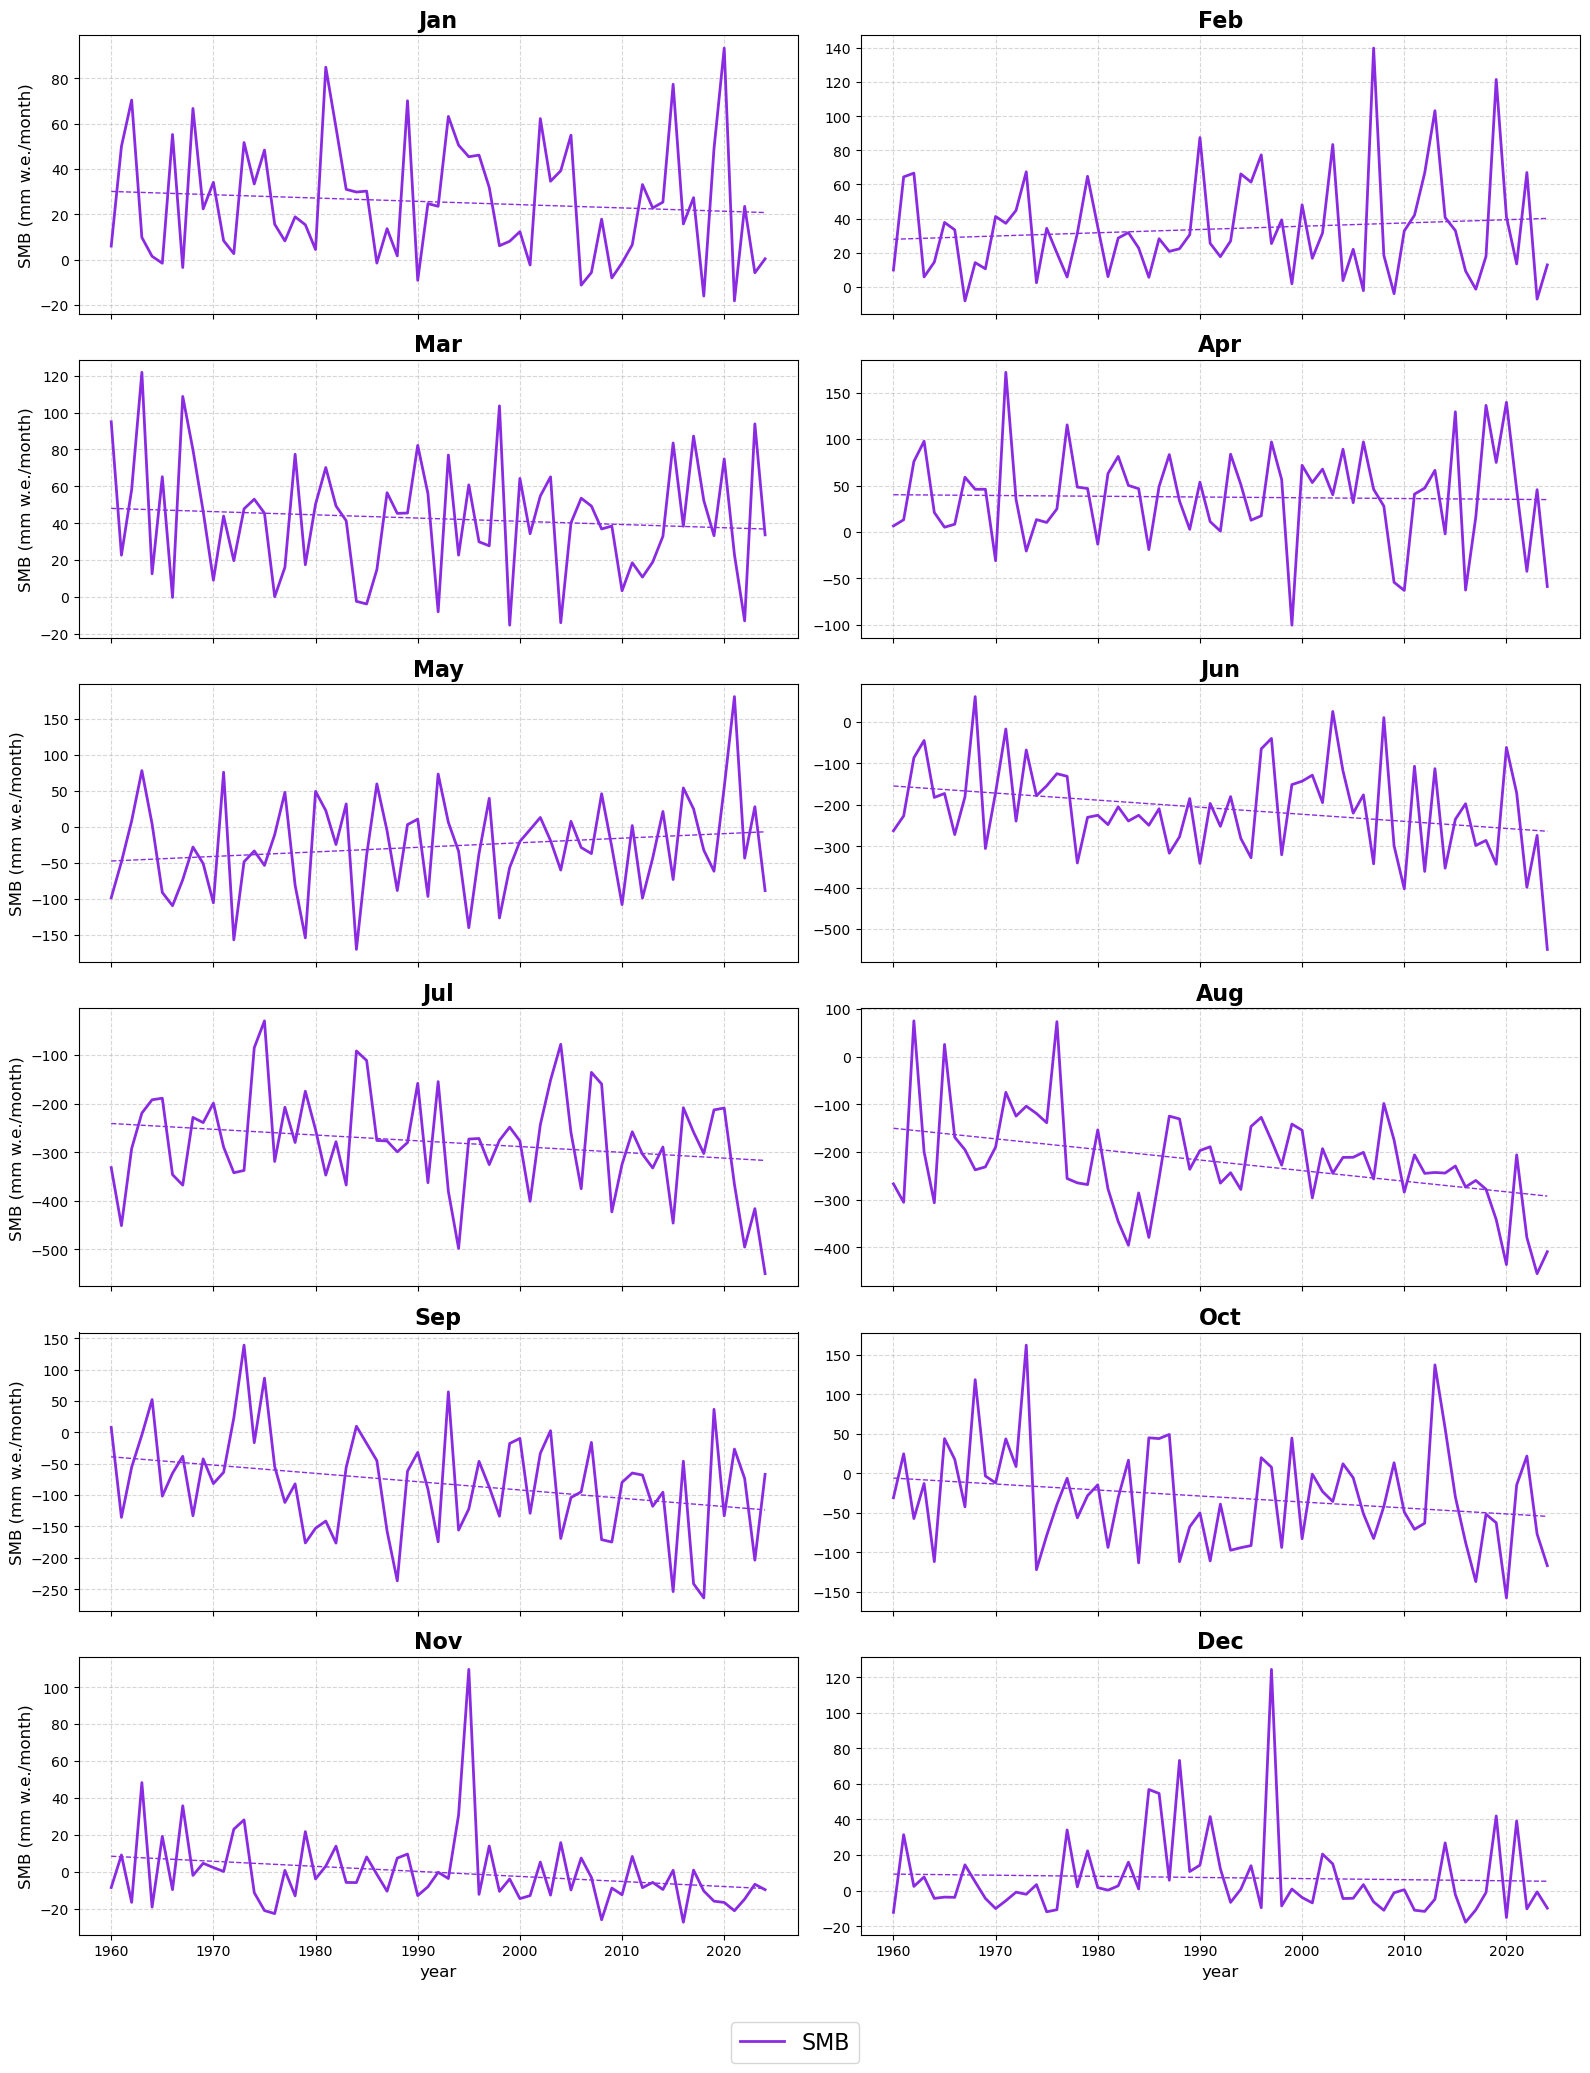

In [13]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

#====================== statistics tab ==============================================================================

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

#========= RF ================
print('==================================================== SMB =================================================')

table = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])

for i in np.arange(1,13):

    SMB_slope = SMB_monthly_trends_stats[i][0] * 10
    SMB_pval  = SMB_monthly_trends_stats[i][3]
    SMB_slope_percentage = SMB_slope /  SMB_monthly_stats[i][0] * 100
    SMB_std = SMB_monthly_stats[i][1]
    SMB_std_percentage = SMB_std /  SMB_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (mm/month/decade)'] = SMB_slope
    table.loc[months[i-1], 'slope (%/decade)'] = SMB_slope_percentage
    table.loc[months[i-1], 'std (mm/month)'] = SMB_std
    table.loc[months[i-1], 'std (%)'] = SMB_std_percentage

    
    pvals.loc[months[i-1], 'slope (mm/month/decade)'] = SMB_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = SMB_pval

formats = {
    'slope (mm/month/decade)': "{:.2f}",
    'slope (%/decade)': "{:.1f}",
    'std (mm/month)': "{:.2f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#======================== plot ============================================================================================

fig, axes = plt.subplots(6, 2, figsize=(16,20))
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    ax.plot(SMB_monthly_timeseries[i+1]['year'].values, SMB_monthly_timeseries[i+1].values, color='blueviolet', label='SMB', linewidth=2)
    ax.plot(SMB_monthly_timeseries[i+1]['year'].values, SMB_monthly_trends[i+1], color='blueviolet', linewidth=1, linestyle='--')

    ax.set_title(months[i], fontsize=16, weight="bold")
    
    if i in [0, 2, 4, 6, 8, 10]:  # colonne gauche
        ax.set_ylabel('SMB (mm w.e./month)', fontsize=12)
        
    if i in [10, 11]:  # ligne du bas
        ax.set_xlabel('year', fontsize=12)
    else:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
# --- legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
    
plt.tight_layout()
plt.show()